Import packages here

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import photutils
from photutils import aperture as apt
from astropy.table import QTable
from scipy.fftpack import fft, fftfreq
from astropy.timeseries import LombScargle

# 1) Flat Fielding & Bias Subtraction

### Plot the combined, normalized flat image

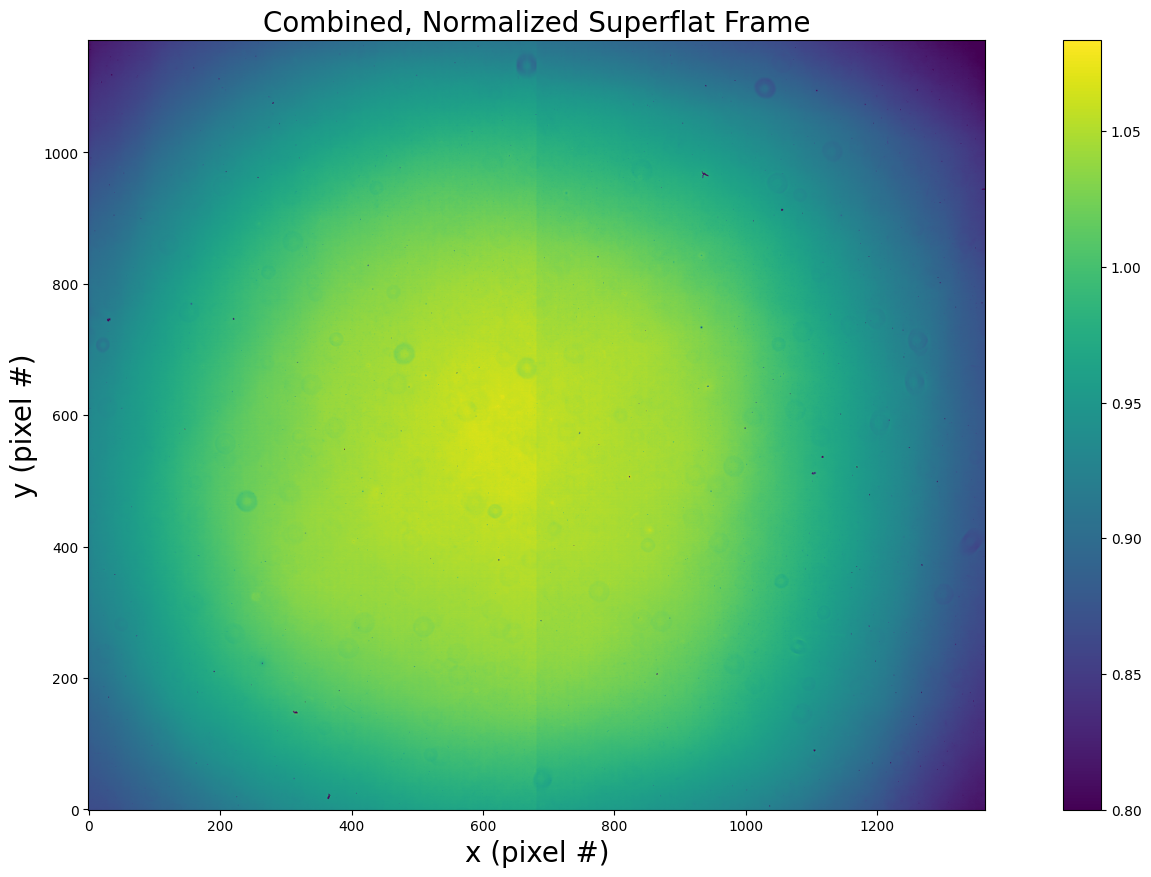

In [2]:
# Access the superflat file
superflat_normalized = fits.getdata("raw_data/sflat.fits")

plt.figure("Superflat", figsize=(20, 10))
plt.title("Combined, Normalized Superflat Frame", size = 20)
plt.imshow(superflat_normalized, origin = 'lower', vmin=0.8)#, vmin = 560, vmax = 565)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

### Plot the combined bias image

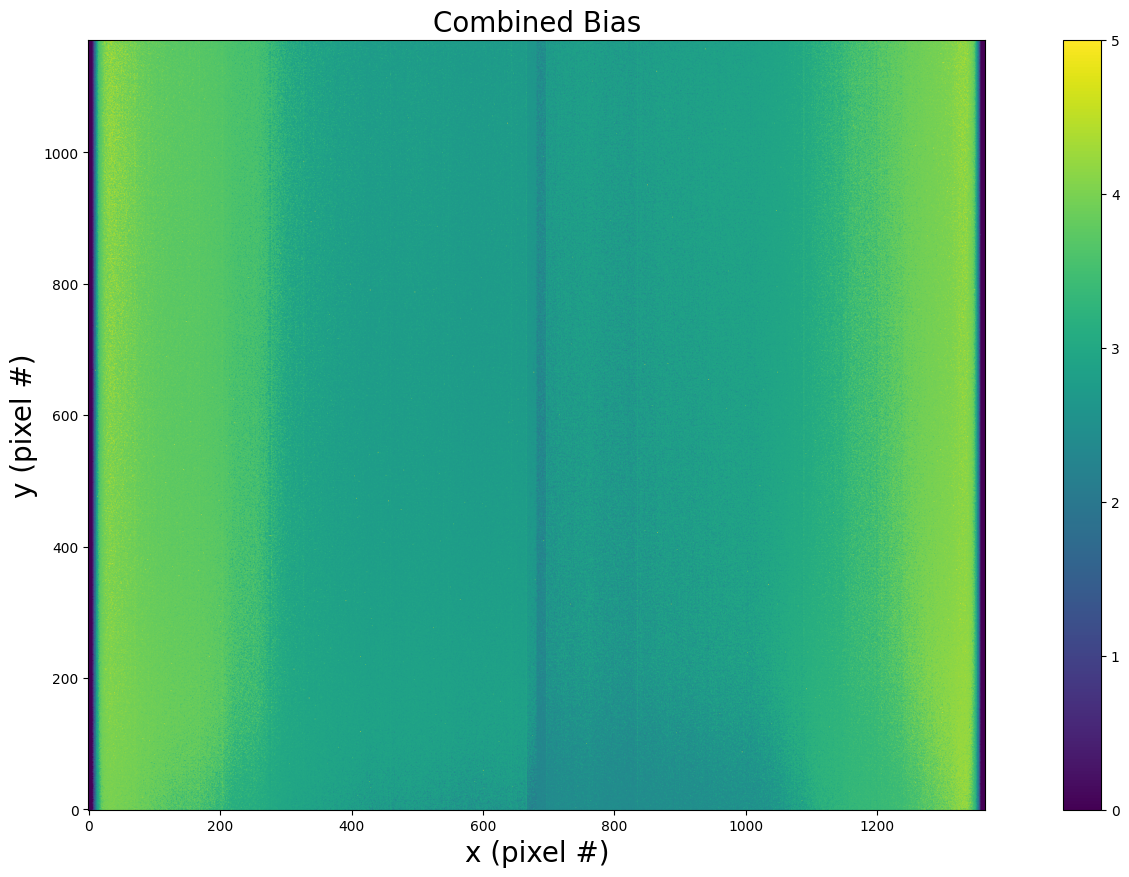

In [3]:
# Access the bias file
superbias = fits.getdata("raw_data/bias.fits")

plt.figure("Bias", figsize=(20, 10))
plt.title("Combined Bias", size = 20)
plt.imshow(superbias, origin = 'lower',vmin=0, vmax=5)#, vmin = 560, vmax = 565)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

### Call in all of the filenames for our raw science images

In [4]:
files = glob.glob('raw_data\\sci_images\\*')
files = np.array(files)

file_nos = np.zeros(len(files))

for i, filename in enumerate(files):
    file_nos[i] = float(filename.split('.')[1])
    
order = np.argsort(file_nos)
files = files[order]

# files ## Debugging

### Apply image correction to all raw science images and write to new set of reduced images

In [ ]:
for f in files:
    print(f)
    # Open the FITS file and read the data
    image = fits.open(f)
    raw_sci = image[0].data
    header = image[0].header
    
    # Apply the bias and superflat corrections
    reduced_sci = (raw_sci - superbias) / superflat_normalized
    
    # Subtract sky background
    skyloc1, skyloc2, skyloc3 = (reduced_sci[260:360,632:732], 
                                reduced_sci[610:710,75:175], 
                                reduced_sci[735:835,1000:1100])
    skymed1, skymed2, skymed3 = np.median(skyloc1), np.median(skyloc2), np.median(skyloc3)
    sky_background = np.median([skymed1, skymed2, skymed3])
    reduced_sci = reduced_sci - sky_background
    
    # Save the reduced image to a new FITS file
    reduced_image = fits.PrimaryHDU(data=reduced_sci, header=header)
    reduced_image.writeto("raw_data\\reduced_sci\\reduced_" + f.split("\\")[-1], overwrite=True)
    
    # Close the image
    image.close()

raw_data\sci_images\2m0753.0001.fits
raw_data\sci_images\2m0753.0002.fits
raw_data\sci_images\2m0753.0003.fits
raw_data\sci_images\2m0753.0004.fits
raw_data\sci_images\2m0753.0005.fits
raw_data\sci_images\2m0753.0006.fits
raw_data\sci_images\2m0753.0007.fits
raw_data\sci_images\2m0753.0008.fits
raw_data\sci_images\2m0753.0009.fits
raw_data\sci_images\2m0753.0010.fits
raw_data\sci_images\2m0753.0011.fits
raw_data\sci_images\2m0753.0012.fits
raw_data\sci_images\2m0753.0013.fits
raw_data\sci_images\2m0753.0014.fits
raw_data\sci_images\2m0753.0015.fits
raw_data\sci_images\2m0753.0016.fits
raw_data\sci_images\2m0753.0017.fits
raw_data\sci_images\2m0753.0018.fits
raw_data\sci_images\2m0753.0019.fits
raw_data\sci_images\2m0753.0020.fits
raw_data\sci_images\2m0753.0021.fits
raw_data\sci_images\2m0753.0022.fits
raw_data\sci_images\2m0753.0023.fits
raw_data\sci_images\2m0753.0024.fits
raw_data\sci_images\2m0753.0025.fits
raw_data\sci_images\2m0753.0026.fits
raw_data\sci_images\2m0753.0027.fits
r

### Plot the raw science image

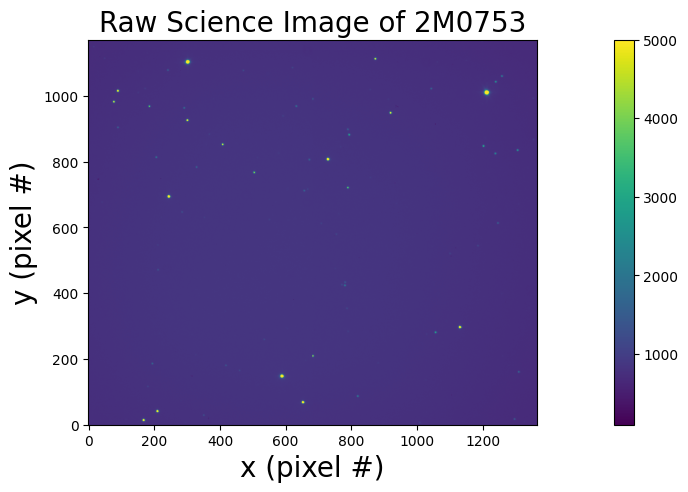

In [2]:
raw_science_image = fits.getdata("raw_data/sci_images/2m0753.0001.fits")

plt.figure('Raw Science Image of 2M0753', figsize = (20, 5))
plt.title('Raw Science Image of 2M0753', size = 20)
plt.imshow(raw_science_image, origin = 'lower',vmin=100, vmax=5000)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim()
plt.ylim()
plt.show()

### Plot a single reduced science image for comparison

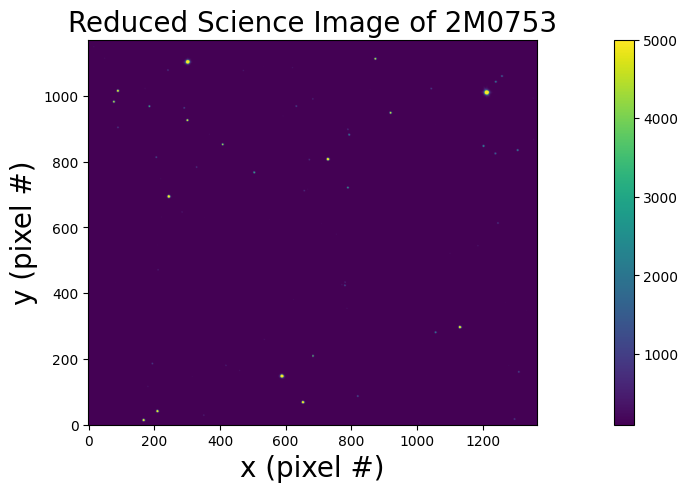

In [3]:
sci_reduced_image = fits.getdata("raw_data\\reduced_sci\\reduced_2m0753.0001.fits")

plt.figure('Reduced Science Image of 2M0753', figsize = (20, 5))
plt.title('Reduced Science Image of 2M0753', size = 20)
plt.imshow(sci_reduced_image, origin = 'lower',vmin=100, vmax=5000)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim()
plt.ylim()
plt.show()

### Call in all of the filenames for our reduced science images

In [4]:
reduced_files = glob.glob('raw_data\\reduced_sci\\*')
reduced_files = np.array(reduced_files)

file_nos = np.zeros(len(reduced_files))

for i, filename in enumerate(reduced_files):
    file_nos[i] = float(filename.split('.')[1])
    
order = np.argsort(file_nos)
reduced_files = reduced_files[order]

# files ## Debugging

Explore the header of a reduced FITS file

In [5]:
sci_reduced_image_header = fits.getheader("raw_data\\reduced_sci\\reduced_2m0753.0001.fits")

sci_reduced_image_header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1365                                                  
NAXIS2  =                 1172                                                  
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2026-03-05T02:12:10' / Date FITS file was generated                  
IRAF-TLM= '2026-03-26T03:34:50' / Time of last modification                     
OBJECT  = '2M0753+2324'        / Name of the object observed                    
CCDSUM  = '3 3     '           / CCD pixel summing                              
CCDBIN1 =                    3 / Binning factor along axis 1                    
CCDBIN2 =                    3 / Binning factor along axis 2                    
FILENAME= 'TempImage2402.fit

# 2) Plot Seeing Over Time

# 3) Aperture Photometry with the Target

### Isolate 2M0753 within a Python plot

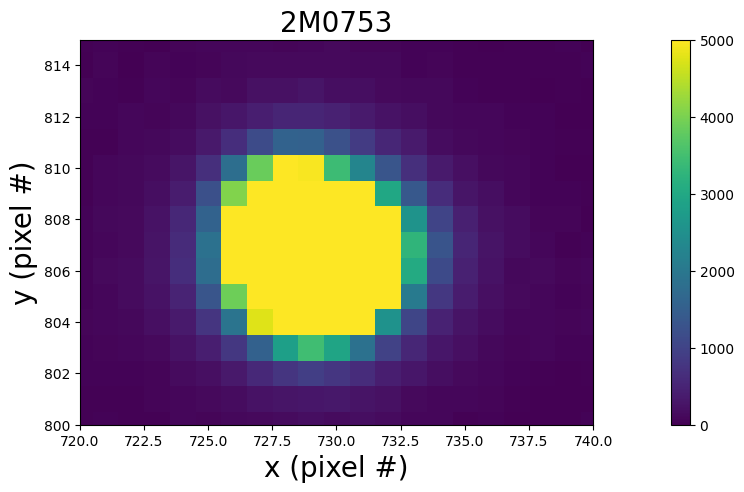

In [6]:
plt.figure('Mont4K CCD - WISE 0855', figsize = (20, 5))
plt.title('2M0753', size = 20)
plt.imshow(sci_reduced_image, vmin=0, vmax = 5000, origin = 'lower')
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim(720,740)
plt.ylim(800,815)
plt.show()

### Extract the average FWHM for the target (and reference stars) from the file `2m0753.stats`

In [7]:
info_file = "raw_data/2m0753.stats"
fwhm_values = []

with open(info_file, 'r') as f:
    for line in f:
        # Turn each line into a list of value
        line = line.strip("\n").split(" ")
        
        # Skip the headers
        if "2m0753" not in line[0]:
            continue
        
        # Extract the FWHM value and append it to the list
        fwhm_values.append(float(line[-2]))
f.close()
# print(fwhm_values) ## Debugging

### Create and Center an Extraction Radius and Annulus for 2M0753 (with the first reduced image)

In [8]:
target_center_pixel_x = 729  #center of target location (x) in pixels
target_center_pixel_y = 808  #center of target location (y) in pixels
target_aperture_radius = 2.25*fwhm_values[0]   # radial width of extraction in pixels (suggested by Dr. Green)
r_in = 13             # inner radius of background annulus in pixels (suggested by Dr. Green)
r_out = 18            # outer radius of background annulus in pixels (suggested by Dr. Green)
target_aperture = apt.CircularAperture((target_center_pixel_x, target_center_pixel_y), r=target_aperture_radius) 
target_annulus = apt.CircularAnnulus((target_center_pixel_x, target_center_pixel_y), r_in, r_out)

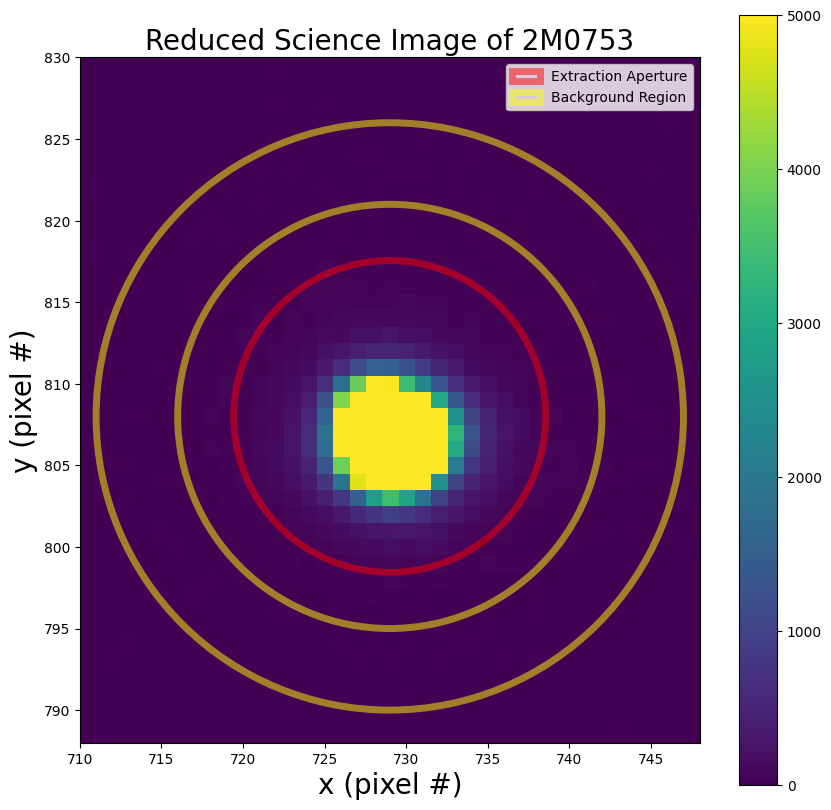

In [9]:
plt.figure('Mont4K CCD Image of 2M0753', figsize = (10, 10))
plt.title('Reduced Science Image of 2M0753', size = 20)
plt.imshow(sci_reduced_image, vmin = 0, vmax = 5000, origin = 'lower')
target_aperture.plot(color='red', lw=5, alpha=0.5, label = 'Extraction Aperture')
target_annulus.plot(color='yellow', lw=5, alpha=0.5, label = 'Background Region')
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim([710,748])
plt.ylim([788,830])
plt.legend()
plt.show()

### Perform aperture photometry of 2M0753 for all reduced science images

In [10]:
# Empty arrays to hold the flux & flux error values for each image and time values, respectively
target_extracted_flux_values = []
target_extracted_flux_errors = []
time_stamps = []

index = 0 # Counter for the fwhm values, which are in the same order as the reduced images 
            # and will be used to set the aperture sizes for photometry
            
for f in reduced_files:
    # Read in the individual reduced science image from the file
    individual_reduced_sci_image = fits.getdata(f) 
    
    # Extract the HJD from header and add to time array (for plotting light curve)
    header = fits.getheader(f)
    hjd = header['HJD'] - 2461104 ## Convert to time since first observation
    time_stamps = np.append(time_stamps, hjd)
    
    # Apply aperture extraction
    target_center_pixel_x = 729  #center of target location (x) in pixels
    target_center_pixel_y = 808  #center of target location (y) in pixels
    target_aperture_radius = 2.25*fwhm_values[index]   # Optimal radial width of extraction in pixels (suggested by Dr. Green)
    r_in = 13             # inner radius of background annulus in pixels (suggested by Dr. Green)
    r_out = 18            # outer radius of background annulus in pixels (suggested by Dr. Green)
    target_aperture = apt.CircularAperture((target_center_pixel_x, target_center_pixel_y), r=target_aperture_radius) # Aperture
    target_annulus = apt.CircularAnnulus((target_center_pixel_x, target_center_pixel_y), r_in, r_out) # Annulus
    target_phot_table = photutils.aperture.aperture_photometry(individual_reduced_sci_image, target_aperture)
    
    # Extract the flux value and append to the flux array
    target_flux = target_phot_table['aperture_sum'][0]
    target_extracted_flux_values = np.append(target_extracted_flux_values, target_flux)
    
    # Calculate the flux error and append to the flux error array
    bkg_stats = photutils.aperture.ApertureStats(individual_reduced_sci_image, target_annulus)
    bkg_sigma = bkg_stats.std
    target_flux_err = np.sqrt(target_aperture.area)*bkg_sigma
    target_extracted_flux_errors = np.append(target_extracted_flux_errors, target_flux_err)
    
    # Increase the index counter to set the average FWHM for the next image
    index += 1

# Convert the time, flux, and flux error arrays to numpy arrays for plotting
time_stamps = np.array(time_stamps)
target_extracted_flux_values = np.array(target_extracted_flux_values)
target_extracted_flux_errors = np.array(target_extracted_flux_errors)

## Debugging
# print(target_extracted_flux_values)
# print(target_extracted_flux_errors)

### Plot Seeing Over Time

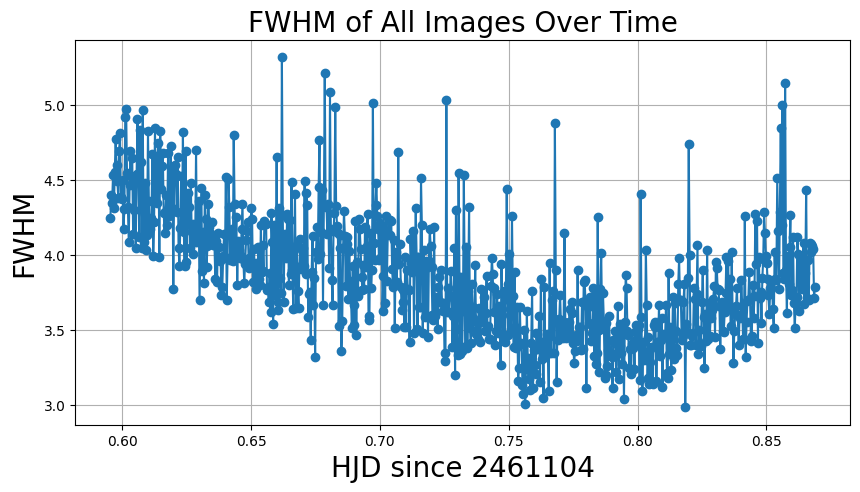

In [11]:
plt.figure("Seeing Over Time", figsize=(10,5))
plt.title("FWHM of All Images Over Time", size=20)
plt.plot(time_stamps, fwhm_values, marker = 'o')
plt.xlabel('HJD since 2461104', size = 20)
plt.ylabel('FWHM', size = 20)
plt.grid()
plt.show()

### Check if any flux uncertainties are negative (for plotting)(optional)

In [12]:
# for i in range(len(target_extracted_flux_errors)):
#     if target_extracted_flux_errors[i] < 0:
#         print(i)
#         print(target_extracted_flux_errors[i])

### Plot 2M0753's Raw Flux Over Time with Error Bars

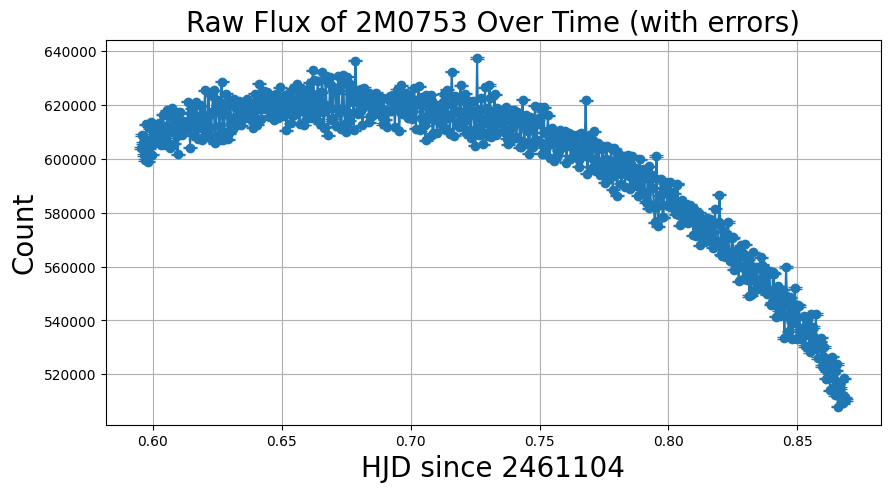

In [13]:
plt.figure("Light Curve of 2M0753 with Errors", figsize = (10, 5))
plt.title("Raw Flux of 2M0753 Over Time (with errors)", size = 20)
plt.errorbar(time_stamps, target_extracted_flux_values, yerr = target_extracted_flux_errors, marker = 'o', capsize = 5)
plt.xlabel('HJD since 2461104', size = 20)
plt.ylabel('Count', size = 20)
#plt.xlim(0.6,0.65)
#plt.ylim(10,22)
plt.grid()
plt.show()

# 4) Aperture Photometry with Reference Stars and Normalize Flux of science targets

### Extract flux and flux errors of all reference stars

In [14]:
# Arrays of location (x,y) of all 11 reference stars
ref_location = np.array([[653.16,70.03],
                        [1130.54,298.10],
                        [245.35,694.94],
                        [789.93,721.77],
                        [1306.31,835.58],
                        [1202.37,848.19],
                        [409.20,853.11],
                        [301.97,926.50],
                        [919.89,949.05],
                        [90.50,1015.82],
                        [873.49,1113.11]])

# Background annulus radii
r_in = 13             ## inner radius of background annulus in pixels (suggested by Dr. Green)
r_out = 18            ## outer radius of background annulus in pixels (suggested by Dr. Green)

# Empty arrays to hold the flux & flux error values for each image and time values, respectively
allref_extracted_flux_values = []
allref_extracted_flux_errors = []
       
# Perform aperture photometry for each reference star
for x_ref, y_ref in ref_location:
    ref_extracted_flux_values = []
    ref_extracted_flux_errors = []
    for i, filename in enumerate(reduced_files):
        # Read in the individual reduced science image from the file
        individual_reduced_sci_image = fits.getdata(filename)
        
        # Apply aperture extraction
        ref_aperture_radius = 2.25*fwhm_values[i]   # Optimal radial width of extraction in pixels (suggested by Dr. Green)
        ref_aperture = apt.CircularAperture((x_ref, y_ref), r=ref_aperture_radius) # Aperture
        ref_annulus = apt.CircularAnnulus((x_ref, y_ref), r_in, r_out) # Annulus
        
        # Extract the flux value and append to the flux array
        ref_phot_table = photutils.aperture.aperture_photometry(individual_reduced_sci_image, ref_aperture)
        ref_flux = ref_phot_table['aperture_sum'][0]
        ref_extracted_flux_values.append(ref_flux)
        
        # Calculate the flux error and append to the flux error array
        bkg_stats = photutils.aperture.ApertureStats(individual_reduced_sci_image, ref_annulus)
        bkg_sigma = bkg_stats.std
        ref_flux_err = np.sqrt(ref_aperture.area)*bkg_sigma
        ref_extracted_flux_errors.append(ref_flux_err)

    # Append to the main flux and flux error arrays
    allref_extracted_flux_values.append(ref_extracted_flux_values)
    allref_extracted_flux_errors.append(ref_extracted_flux_errors)

# Convert the main flux and flux error arrays to numpy arrays for plotting
allref_extracted_flux_values = np.array(allref_extracted_flux_values)
allref_extracted_flux_errors = np.array(allref_extracted_flux_errors)

## Debugging
#print(allref_extracted_flux_values.shape)
#print(allref_extracted_flux_errors)

### Plot light curves of target and reference stars

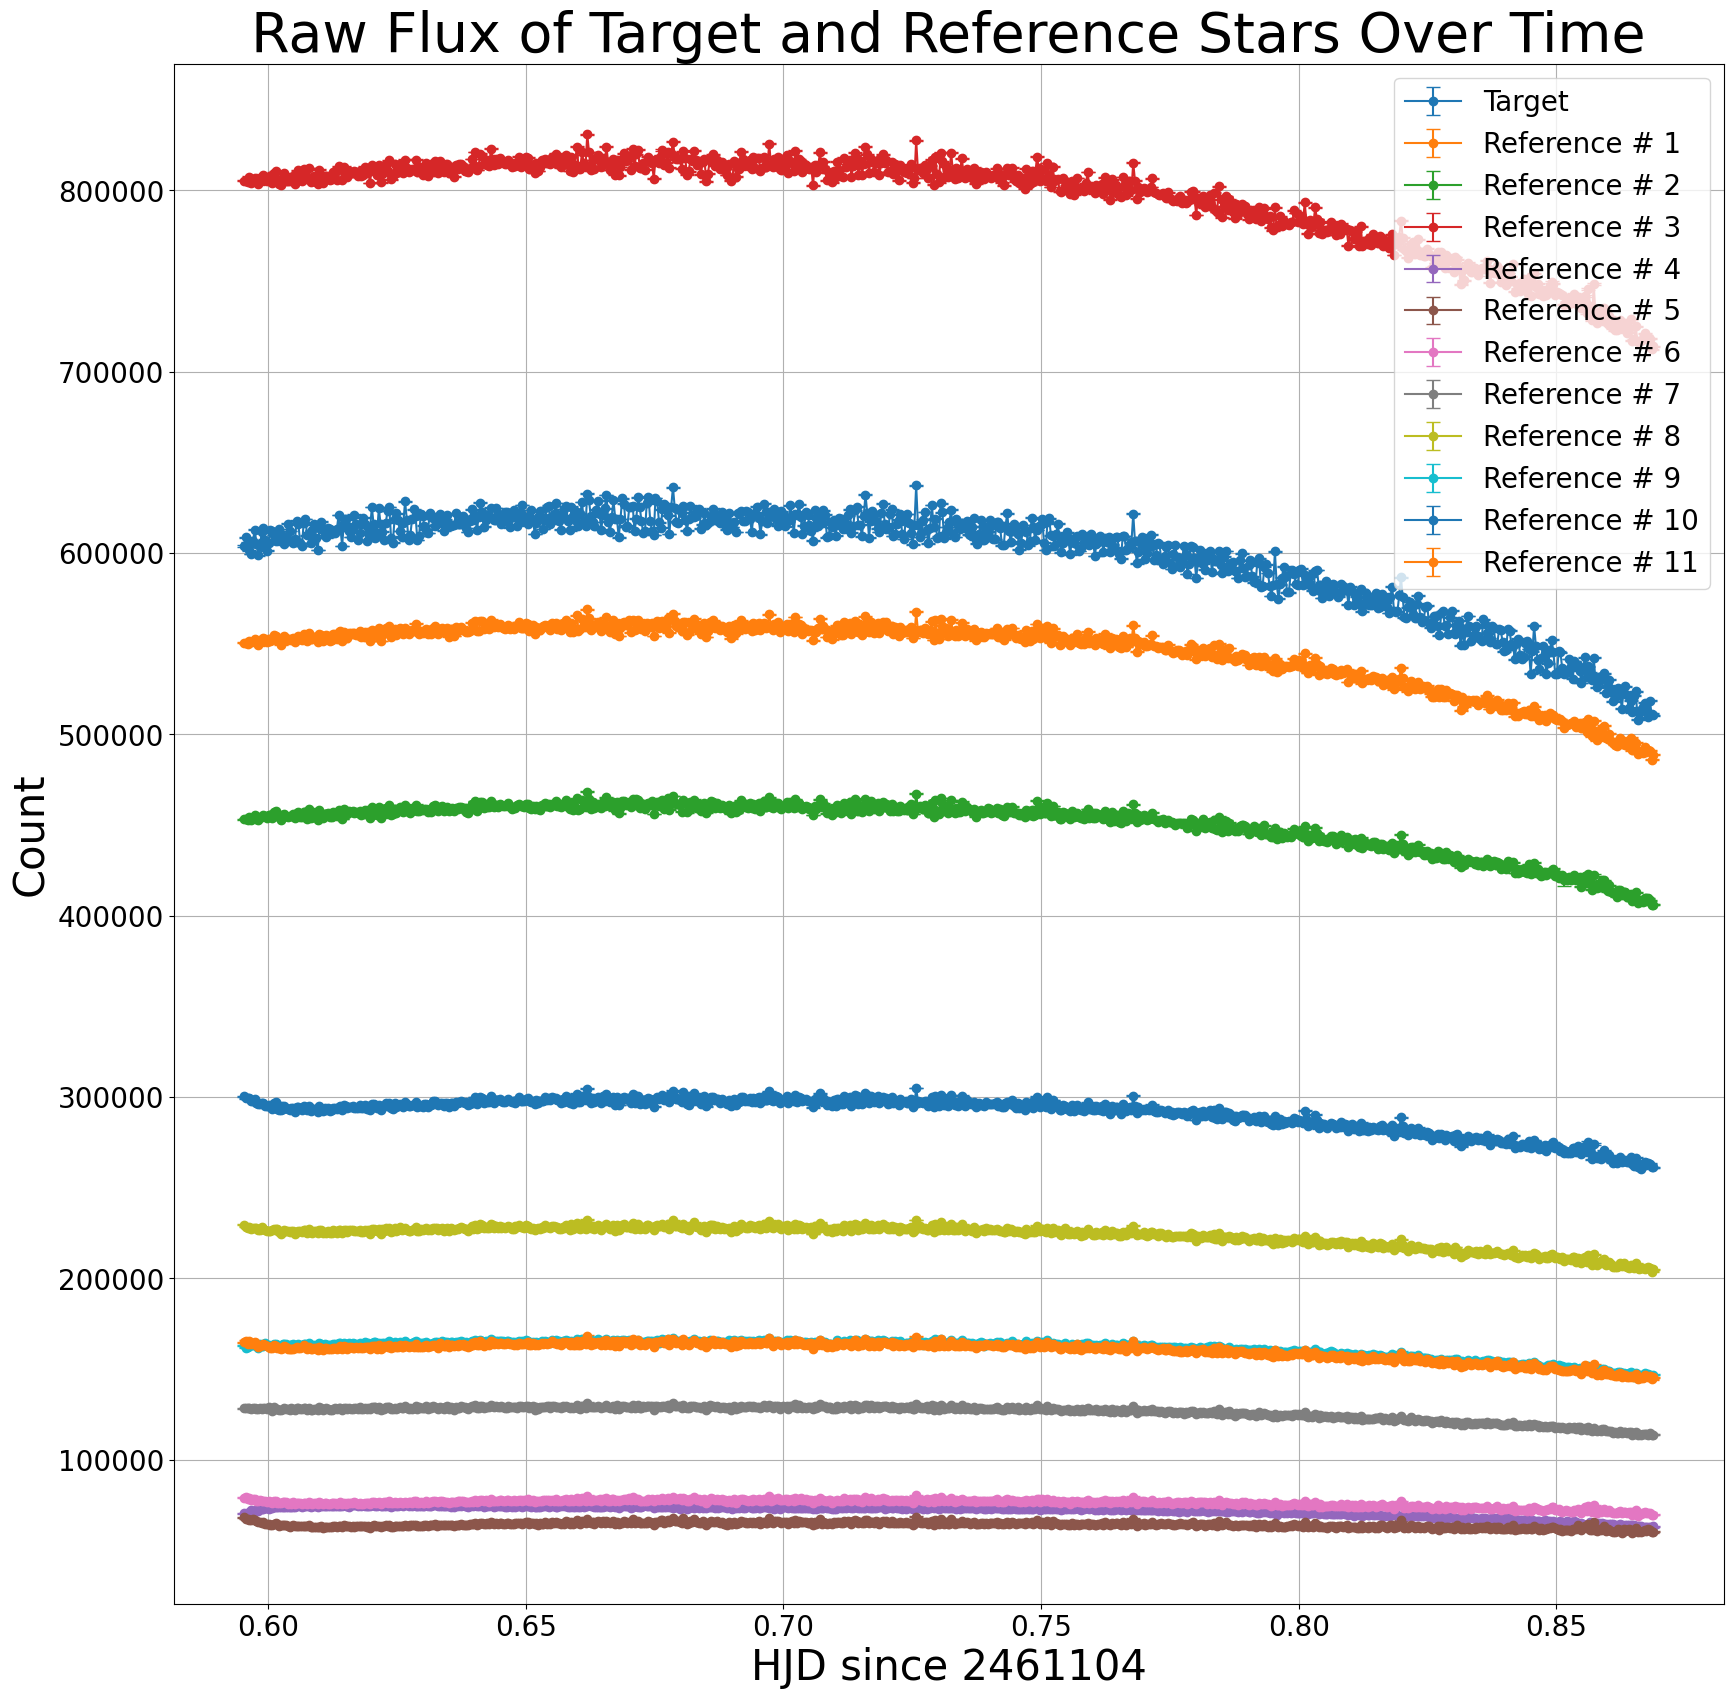

In [15]:
plt.figure("Light Curve of Target and Reference Stars with Errors", figsize = (20, 20))
plt.title("Raw Flux of Target and Reference Stars Over Time", size = 40)

# Plot the light curve of the target star with error bars
plt.errorbar(time_stamps, target_extracted_flux_values, yerr = target_extracted_flux_errors, marker = 'o', capsize = 5)

# Plot the light curves of the reference stars with error bars
for i in range(allref_extracted_flux_values.shape[0]):
    plt.errorbar(time_stamps, allref_extracted_flux_values[i], yerr = allref_extracted_flux_errors[i], marker = 'o', capsize = 5)

# Legend
plt.legend(['Target', 
            'Reference # 1', 
            'Reference # 2', 
            'Reference # 3', 
            'Reference # 4', 
            'Reference # 5', 
            'Reference # 6', 
            'Reference # 7', 
            'Reference # 8', 
            'Reference # 9', 
            'Reference # 10', 
            'Reference # 11'], 
           loc = "upper right",
           title_fontsize = 25,
           fontsize = 20)

plt.xlabel('HJD since 2461104', size = 30)
plt.xticks(size=20)
plt.ylabel('Count', size = 30)
plt.yticks(size=20)
# plt.xlim(0.6,0.65)
#plt.ylim(6e5,7e5)
plt.grid()
plt.show()

### Normalize the flux of target with mean of fluxes of all reference stars and plot

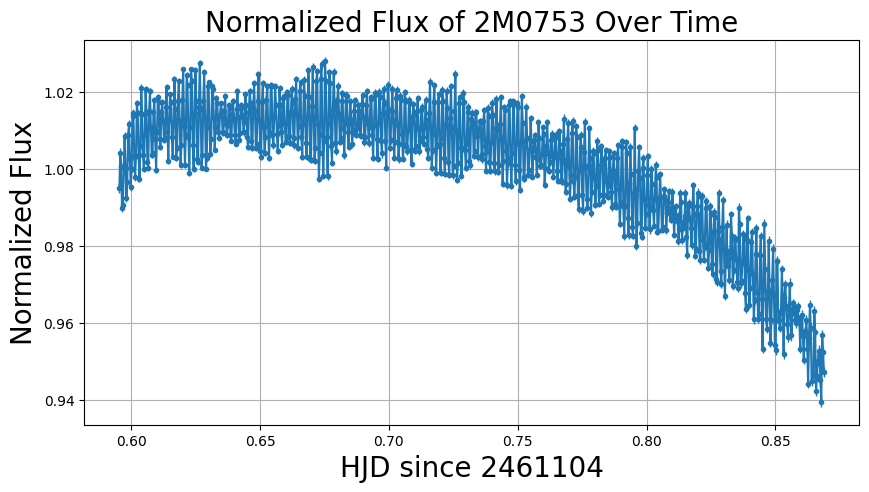

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(10,5))
plt.title("Normalized Flux of 2M0753 Over Time", size = 20)

# Normalize the target flux by the average flux of the reference stars at each time point (Photometric correction)
average_ref_flux = np.mean(allref_extracted_flux_values, axis=0) ## Also call this photometric correction factor
#print(average_ref_flux) ## Debugging
normalized_target_flux = target_extracted_flux_values / average_ref_flux
normalized_target_flux /= np.mean(normalized_target_flux)
error_pc = np.sqrt(np.sum(allref_extracted_flux_errors**2, axis=0))/np.shape(allref_extracted_flux_errors)[0] ## Error of the photometric correction factor
normalized_target_flux_error = np.sqrt(target_extracted_flux_errors**2 + (target_extracted_flux_values*error_pc/average_ref_flux)**2)/average_ref_flux 
    ## Total error of the normalized flux, which includes the error of the target flux and the error of the photometric correction factor

plt.errorbar(time_stamps, normalized_target_flux, yerr=normalized_target_flux_error, marker = 'o', markersize=3, elinewidth=1)
plt.xlabel('HJD since 2461104', size = 20)
plt.ylabel('Normalized Flux', size = 20)
# plt.xlim(0.6,0.65)
#plt.ylim(10,22)
plt.grid()
plt.show()
plt.savefig("normalized_light_curve_2m0753.png")

# 5) Write the data text file for 2M0753

In [17]:
# Convert the time stamps back to original HJD values before sending data to Dr. Green
converted_time_stamps = time_stamps + 2461104 - 2461000

# Write the text file to send to Dr. Green with the converted time stamps, flux values, and flux errors
normalized_data = QTable([converted_time_stamps, normalized_target_flux], names = ['HJD', 'Normalized Flux (Count)'])
normalized_data.write("normalized_data.csv", format = "csv", overwrite = True)

# 6) Lomb-Scargle Periodogram

### Lomb-Scargle Calculation

In [22]:
# Remove bad values
good = (
    np.isfinite(time_stamps) &
    np.isfinite(normalized_target_flux) &
    np.isfinite(normalized_target_flux_error) &
    (normalized_target_flux_error > 0)
)
time_stamps = time_stamps[good]
normalized_target_flux = normalized_target_flux[good]
normalized_target_flux_error = normalized_target_flux_error[good]

# Sort by time
sorted_indices = np.argsort(time_stamps)
time_stamps = time_stamps[sorted_indices]
normalized_target_flux = normalized_target_flux[sorted_indices]
normalized_target_flux_error = normalized_target_flux_error[sorted_indices]

# Remove slow trend from normalized flux
trend_coeff = np.polyfit(time_stamps, normalized_target_flux, 2)
trend = np.polyval(trend_coeff, time_stamps)
detrended_normalized_flux = normalized_target_flux / trend
detrended_normalized_flux -= np.mean(detrended_normalized_flux)

# Compute Nyquist frequency and frequency grid for Lomb-Scargle periodogram
dt = np.diff(time_stamps)
median_dt = np.median(dt)
nyquist_freq = 0.5 / median_dt

# Set frequency grid for Lomb-Scargle periodogram
min_freq = 100
max_freq = nyquist_freq
samples_per_peak = 10

# Perform Lomb-Scargle periodogram analysis
ls = LombScargle(time_stamps, detrended_normalized_flux, normalized_target_flux_error)
freq, power = ls.autopower(minimum_frequency=min_freq, maximum_frequency=max_freq, samples_per_peak=samples_per_peak)

# Calculate the 1% false alarm probability level
fal = ls.false_alarm_level(
    0.01,
    minimum_frequency=min_freq,
    maximum_frequency=max_freq,
)

# Find strongest peak below Nyquist frequency
best_freq = freq[np.argmax(power)]
best_power = power[np.argmax(power)]
best_period = (1 / best_freq)*86400 # Convert from days to seconds
print(f"Best frequency: {best_freq} cycles/day")
print(f"Best period: {best_period} seconds")
print(f"Best power: {best_power}")

Best frequency: 616.0457495425937 cycles/day
Best period: 140.2493241194358 seconds
Best power: 0.7484193416270267


### Plot the periodogram

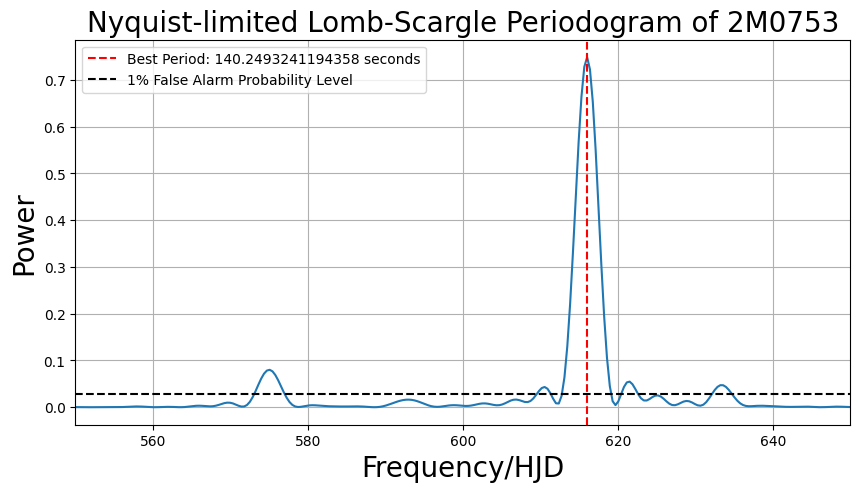

In [28]:
plt.figure("lombscargle", figsize=(10,5))
plt.plot(freq, power)

# Mark the strongest frequency
plt.axvline(best_freq, 
            color='red',
            linestyle='--',
            label=f'Best Period: {best_period} seconds')

# Mark the 1% false alarm probability level
plt.axhline(fal,
            color='black',
            linestyle='--',
            label='1% False Alarm Probability Level')

plt.title("Nyquist-limited Lomb-Scargle Periodogram of 2M0753", size=20)
plt.xlabel('Frequency/HJD', size = 20)
plt.ylabel('Power', size = 20)
plt.legend()
plt.xlim(550,650)
# plt.ylim(-0.05,1.05)
plt.grid()
plt.show()